# Clase 15: Selección de Características y Ajuste de Hiperparámetros

**MDS7202: Laboratorio de Programación Científica para Ciencia de Datos**

## Objetivos

- Comprender la importancia de seleccionar características.
- Seleccionar Características relevantes.
- Integrar estas técnicas con `Pipeline`.
- Buscar la mejor configuración de hiperparámetros con `GridSearch`.

> **Pregunta motivacional:** ¿Agregar más variables a un modelo siempre mejora su desempeño? ¿Qué podría salir mal si usamos demasiadas características?

## Importamos Librerías

In [325]:
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler
import warnings

warnings.filterwarnings("ignore")

df = pd.read_csv("../../recursos/2023-01/22_hiper/descriptores_musica.csv")
df = df.astype({"time_signature": str, "key": str, "mode": str})

---

## El Problema: Caracterización Musical 🎸🤘🎼🎵

<center>
<img src='https://media.tenor.com/2HL1y7peaysAAAAM/2pac-hit-em-up.gif' width=250 />

Los atributos son: 

- `key`: escala de la canción. 0 = C, 1 = C♯/D♭, 2 = D...  [Mas información](https://en.wikipedia.org/wiki/Pitch_class).
- `mode`: 1 si la escala es mayor, 0 si es menor.
- `time_signature`: cuántos pulsos hay en cada compás. (4, 3,...).
- `loudness`: Volumen de la canción (rango -60, 0).


- `acousticness`: Probabilidad de que la canción sea solo acústica. Valores cercanos a 1 indican que la canción es probablemente acústica.
- `danceability`: Describe que tan bailable es la canción. Valores cercanos a 1 indican que la canción es muy bailable.
- `energy`: Mide que tan energética es una canción. Mide cosas como la rapidez, el volumen y el ruido. Valores cercanos a 1 indican que la canción es muy enérgica.
- `instrumentalness`: Probabilidad de que la canción sea instrumental. Valores cercanos a 1 indican que la canción probablemente **no tiene voces cantadas**.
- `liveness`: Probabilidad de que la canción fuese grabada en vivo. 1 es muy probable que la canción haya sido grabada en vivo.
- `speechiness`: Probabilidad de que la canción contenga palabras habladas (ejemplo: podcast : 1). 
- `valence`: Sentimiento de la canción (rango 0, 1). 1 -> felicidad, alegria, euforia. 0 -> Tristeza, enojo, depresión.
- `tempo` : Pulsos por minuto de la canción (BPM). 


La variable a predecir es: 

- `genre`: Género de la canción.

## Motivación: ¿Por qué seleccionar características?

### ¿Qué tan relacionadas están las variables entre sí?


$$corr (X, Y) = \frac{1}{(s_{x} s_{y})} \sum_{i=1}^{m} (x_i - \overline{x})(y_i - \overline{y}) $$


Los valores varían entre -1 y 1

- Positivo: Relación directa: Crece una, crece la otra. Mientras mayor, más similares son las variables.
- Negativo: Relación inversa: Crece una, decrece la otra.

In [326]:
correlations_df = df[
    [
        "danceability",
        "energy",
        "loudness",
        "speechiness",
        "acousticness",
        "instrumentalness",
        "liveness",
        "valence",
        "tempo",
    ]
]
correlations = correlations_df.corr()


px.imshow(
    correlations,
    labels=dict(x="", y="", color="Correlation"),
    x=correlations_df.columns,
    y=correlations_df.columns,
    zmin=-1,
    zmax=1,
    color_continuous_scale="Inferno",
)

### ¿Qué tan relacionadas están con la variable objetivo?

In [327]:
labels = df.loc[:, ["genre"]]
labels

,genre
0,Reggaeton
1,Reggaeton
2,Reggaeton
3,Reggaeton
4,Reggaeton
...,...
809,Pop
810,Pop
811,Pop
812,Pop


In [328]:
encoder = OneHotEncoder(sparse_output=False)
encoded_labels = encoder.fit_transform(labels)

encoded_labels_df = pd.DataFrame(
    encoded_labels, columns=encoder.get_feature_names_out()
)
encoded_labels_df

,genre_Clasica,genre_Disco,genre_Electronica,genre_Hiphop,genre_Jazz,genre_Pop,genre_Reggaeton,genre_Rock,genre_Rock latino
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
809,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
810,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
811,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
812,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [329]:
correlations_labels_df = pd.concat([correlations_df, encoded_labels_df], axis=1)

correlations_labels = correlations_labels_df.corr("pearson").iloc[9:, 0:9]

px.imshow(
    correlations_labels,
    labels=dict(x="", y="", color="Correlation"),
    x=correlations_labels.columns,
    y=correlations_labels.index,
    zmin=-1,
    zmax=1,
    color_continuous_scale="PRgn",
)

### ¿Vale la pena usar el artista como variable?

In [330]:
df["artist"].value_counts()

artist
Daddy Yankee                          6
Johann Sebastian Bach                 6
John Coltrane                         6
Wisin & Yandel                        5
Don Omar                              5
                                     ..
Edward Sharpe & The Magnetic Zeros    1
Portugal. The Man                     1
Leona Lewis                           1
The Script                            1
Rachel Platten                        1
Name: count, Length: 506, dtype: int64

In [331]:
px.histogram(
    df,
    "artist",
)

In [332]:
artista_ohe = OneHotEncoder(sparse_output=False)
artista_encoded = artista_ohe.fit_transform(df[["artist"]])
artista_cols = artista_ohe.get_feature_names_out()


artista_df = pd.DataFrame(artista_encoded, columns=artista_cols)
artista_df

,artist_2Pac,artist_A Taste Of Honey,artist_A Tribe Called Quest,artist_AC/DC,artist_AWOLNATION,artist_Aaron Copland,artist_Adele,artist_Aerosmith,artist_Afu-Ra,artist_Alec Benjamin,...,artist_ZZ Top,artist_Zedd,artist_Zion,artist_Zion & Lennox,artist_Zoé,artist_Zurdok,artist_deadmau5,artist_lovelytheband,artist_Ñejo,artist_Ñejo & Dalmata
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
809,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
810,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
811,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
812,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**Esta transformación produce 506 dimensiones: una por cada artista distinto en el dataset. Agregar esta columna multiplica el espacio de representación de forma enorme, haciendo que los datos se vuelvan extremadamente escasos.**

> **Pregunta:** ¿La cantidad de dimensiones influirá en la calidad de clasificación que logremos?

Imagínense ahora las correlaciones de cada una de estas variables con respecto a la variable de salida.

In [ ]:
artista_df.info()

> **Pregunta motivacional ❓:** Imagina que buscas un punto rojo en una línea de 1 metro: fácil. Ahora en un cuadrado de 1×1 m: más difícil. Ahora en un cubo de 1×1×1 m. ¿Qué pasa cuando tienes 100 dimensiones? ¿Cómo afecta esto a un clasificador que intenta separar clases en el espacio de features?

### Maldición de la Dimensionalidad

La maldición de la dimensionalidad es el problema que consiste en que a medida que aumentan las dimensiones, los datos tienden a hacerse cada vez más *sparse* (escasos) sobre el espacio en el cual están representados. Una simple analogía para entender esto es que:

> *A medida que aumenta la cantidad de características, aumenta el volumen en donde se encuentran los datos, haciendo que estos se separen cada vez más entre sí.*



<div align='center'>
    <img src='https://github.com/MDS7202/MDS7202/blob/main/recursos/2023-01/22_hiper/curse.png?raw=true' width=600/>
</div>

<div align='center'>
    Fuente: <a href='https://www.researchgate.net/figure/The-effect-of-the-curse-of-dimensionality-when-projected-in-1-one-dimension-2-two_fig3_342638066'> A comprehensive survey of anomaly detection techniques for high dimensional big data en Research Gate.</a>
</div>


Esto implica que, para poder seguir distinguiendo correctamente los datos, se debe aumentar masivamente su cantidad a medida que se aumentan las dimensiones.

**¿En qué nos afecta esto?**

Induce comúnmente a una reducción del rendimiento de los clasificadores y regresores.

Más en Wikipedia: [Curse of dimensionality](https://en.wikipedia.org/wiki/Curse_of_dimensionality).

## Análisis Exploratorio de Datos

In [333]:
df.head(5)

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,id,duration_ms,time_signature,name,artist,genre
0,0.617,0.771,10,-5.586,0,0.1120,0.0384,0.000003,0.1620,0.553,180.002,3nCFiwtuVqVJmnSasApvr3,267747,4,Salgo Pa' la Calle,Daddy Yankee,Reggaeton
1,0.788,0.674,2,-8.392,1,0.0537,0.2810,0.033000,0.0892,0.864,94.997,5I0u5YHYvA6fQZstVCFwqC,214747,4,Dile A Tu Amiga,Ñejo,Reggaeton
2,0.745,0.744,5,-8.230,1,0.0837,0.0266,0.000018,0.0959,0.849,96.026,1FTTvjvgX2Qd9ZJqo36m1C,244663,4,Nada Va Pasar,Yaga Y Mackie,Reggaeton
3,0.782,0.767,9,-7.981,0,0.0871,0.2660,0.000036,0.0947,0.622,88.005,6DxS2ZRl8G3EagHkovYXA2,304091,4,Zun Da Da,Zion,Reggaeton
4,0.702,0.864,1,-5.496,1,0.0818,0.1080,0.000000,0.1870,0.788,94.994,4mM90OUhSN79RRKT0qv4dY,215118,4,Fuera del Planeta,Randy,Reggaeton


In [334]:
df.describe()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,814.000000,814.000000,814.000000,814.000000,814.000000,814.000000,814.000000,814.000000,814.000000,8.140000e+02
mean,0.600392,0.589244,-10.017713,0.090809,0.324999,0.159151,0.181294,0.532020,113.486484,2.838903e+05
std,0.196368,0.268840,6.429775,0.095219,0.342813,0.304559,0.151797,0.268382,26.527836,1.284673e+05
min,0.062300,0.002100,-42.238000,0.023200,0.000017,0.000000,0.031100,0.030800,59.406000,8.426700e+04
25%,0.479250,0.417500,-11.555500,0.036500,0.033450,0.000000,0.090675,0.324000,94.013500,2.112300e+05
50%,0.641500,0.663500,-7.997500,0.047550,0.180000,0.000405,0.122000,0.569000,110.033500,2.512800e+05
75%,0.753000,0.799000,-5.854750,0.098000,0.575250,0.095600,0.226750,0.754000,126.928250,3.087402e+05
max,0.976000,0.989000,-1.446000,0.817000,0.996000,0.958000,0.987000,0.981000,213.990000,1.252322e+06


In [335]:
dt_to_hists = df.loc[
    :,
    [
        "danceability",
        "energy",
        "speechiness",
        "acousticness",
        "instrumentalness",
        "valence",
        "liveness",
        "genre",
    ],
].melt(id_vars=["genre"], var_name="variable", value_name="valor")

px.histogram(
    dt_to_hists, x="valor", color="variable", facet_col="variable", facet_col_wrap=4
).update_layout(showlegend=False)

In [336]:
from sklearn.preprocessing import MinMaxScaler, Normalizer
from umap import UMAP

projection_pipe = Pipeline(
    [
        (
            "Column Transformer",
            ColumnTransformer(
                [("MinMax", MinMaxScaler(), ["duration_ms", "loudness"])],
                remainder="passthrough",
            ),
        ),
        ("Normalize", Normalizer()),
        ("UMAP", UMAP(random_state=88, n_neighbors=20, min_dist=0.15)),
    ]
)


projections = projection_pipe.fit_transform(
    df.loc[
        :,
        [
            "danceability",
            "energy",
            "speechiness",
            "acousticness",
            "instrumentalness",
            "valence",
            "liveness",
            "duration_ms",
            "loudness",
        ],
    ]
)
df_proj = pd.DataFrame(projections, columns=["x", "y"])


df_fig = df.copy()
df_fig = pd.concat([df_fig, df_proj], axis=1)
df_fig["hover_name"] = df_fig["artist"] + " - " + df_fig["name"]

fig = px.scatter(
    df_fig,
    x="x",
    y="y",
    color="genre",
    hover_name="hover_name",
    hover_data=[
        "danceability",
        "energy",
        "speechiness",
        "acousticness",
        "instrumentalness",
        "valence",
    ],
)
fig.show()

## Baseline y Referencia

Los problemas identificados en la sección de motivación apuntan todos hacia la misma dirección: usar más variables no siempre es mejor. Antes de aplicar cualquier técnica de selección, necesitamos definir un **punto de referencia** (*baseline*) contra el cual medir si nuestras mejoras realmente mejoran. Sin un *baseline*, no hay forma objetiva de saber si un cambio fue beneficioso o simplemente ruido.

Durante toda esta clase, el *baseline* será un `DecisionTreeClassifier` entrenado con **todas** las características disponibles, sin ningún tipo de selección previa.

In [337]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

preprocessing = ColumnTransformer(
    [
        (
            "Scale",
            MinMaxScaler(),
            [
                "duration_ms",
                "tempo",
                "loudness",
            ],
        ),
        (
            "One Hot Encoding",
            OneHotEncoder(sparse_output=False, handle_unknown="ignore"),
            [
                "key",
                "mode",
                "artist",
                "time_signature",
            ],
        ),
    ],
    remainder="passthrough",
)

# Creamos nuestro baseline pipeline
baseline_pipe = Pipeline(
    steps=[
        ("Preprocessing", preprocessing),
        ("Tree", DecisionTreeClassifier(random_state=42)),
    ]
)

Aplicamos **holdout** al dataset

In [338]:
from sklearn.model_selection import train_test_split

labels = df.loc[:, "genre"]
features = df.drop(columns=["genre", "id", "name"])

X_train, X_test, y_train, y_test = train_test_split(
    features,
    labels,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=labels,
)

Ahora, definimos el ciclo de Entrenamiento y Evaluación.
La métrica con la cuál evaluaremos el desempeño del clasificador será `f1_score`.

Para esto, definiremos la función `train_and_evaluate` que dado un pipeline y conjuntos de entrenamiento y prueba, entrena un clasificador y retorna su evaluación:



In [339]:
from sklearn.metrics import f1_score


def train_and_evaluate(
    pipe, print_=True, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test
):

    # notar que los datasets son parámetros por defecto.

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    if print_:
        print("Matriz de confusión: \n")
        print(confusion_matrix(y_test, y_pred, labels=pipe.classes_))
        print("\nReporte de Clasificación: \n")
        print(
            classification_report(y_test, y_pred, target_names=pipe.classes_),
        )
    return f1_score(y_test, y_pred, average="macro")


train_and_evaluate(baseline_pipe)

Matriz de confusión: 

[[17  0  0  0  2  0  0  0  1]
 [ 0  9  1  1  0  1  1  1  3]
 [ 0  4  4  3  0  0  0  0  1]
 [ 0  0  1 17  0  1  1  0  0]
 [ 4  0  0  0  6  1  0  2  1]
 [ 0  0  1  1  0 13  0  2  3]
 [ 0  1  0  5  0  0 11  1  2]
 [ 0  4  2  0  1  1  3  9  0]
 [ 0  6  2  0  1  2  1  6  2]]

Reporte de Clasificación: 

              precision    recall  f1-score   support

     Clasica       0.81      0.85      0.83        20
       Disco       0.38      0.53      0.44        17
 Electronica       0.36      0.33      0.35        12
      Hiphop       0.63      0.85      0.72        20
        Jazz       0.60      0.43      0.50        14
         Pop       0.68      0.65      0.67        20
   Reggaeton       0.65      0.55      0.59        20
        Rock       0.43      0.45      0.44        20
 Rock latino       0.15      0.10      0.12        20

    accuracy                           0.54       163
   macro avg       0.52      0.53      0.52       163
weighted avg       0.53    

0.517891199768865

In [340]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from sklearn.metrics import classification_report


def classification_report_diff(
    pipe_new,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
):
    """
    Entrena pipe_new y retorna un DataFrame con el cambio porcentual (Δ%) de
    cada métrica del classification_report respecto al _baseline_report global.
    Rows = clases + promedios; cols = precision / recall / f1-score.
    """
    pipe_new.fit(X_train, y_train)
    df_new = pd.DataFrame(
        classification_report(y_test, pipe_new.predict(X_test), output_dict=True)
    ).T
    diff = (df_new - _baseline_report) / _baseline_report.replace(0, np.nan).abs() * 100
    return diff[["precision", "recall", "f1-score"]]


def plot_classification_report_diff(diff_df, title="Mejora respecto al Baseline (%)"):
    """
    Heatmap Plotly del DataFrame de classification_report_diff.
    Verde = mejora · Rojo = deterioro · Blanco = sin cambio.
    """
    df_plot = diff_df.dropna(how="all")
    z = df_plot.values
    text = [[f"{v:+.1f}%" if not np.isnan(v) else "N/A" for v in row] for row in z]
    fig = go.Figure(
        go.Heatmap(
            z=z,
            x=df_plot.columns.tolist(),
            y=df_plot.index.tolist(),
            colorscale="RdYlGn",
            zmid=0,
            text=text,
            texttemplate="%{text}",
            colorbar=dict(title="Δ%"),
            hovertemplate="%{y} — %{x}<br>Cambio: %{text}<extra></extra>",
        )
    )
    fig.update_layout(
        title=title,
        xaxis_title="Métrica",
        yaxis_title="Clase / Promedio",
        height=max(350, 70 + len(df_plot) * 38),
        margin=dict(l=160),
    )
    fig.show()


In [341]:
# Reporte base guardado como referencia para todas las comparaciones
_baseline_report = pd.DataFrame(
    classification_report(y_test, baseline_pipe.predict(X_test), output_dict=True)
).T[["precision", "recall", "f1-score"]]
_baseline_report


,precision,recall,f1-score
Clasica,0.809524,0.850000,0.829268
Disco,0.375000,0.529412,0.439024
Electronica,0.363636,0.333333,0.347826
Hiphop,0.629630,0.850000,0.723404
Jazz,0.600000,0.428571,0.500000
Pop,0.684211,0.650000,0.666667
Reggaeton,0.647059,0.550000,0.594595
Rock,0.428571,0.450000,0.439024
Rock latino,0.153846,0.100000,0.121212
accuracy,0.539877,0.539877,0.539877


> **Pregunta:❓** ¿Cómo sé que mi modelo es mejor que uno que clasifica al azar?


### Modelos Dummy

<center>
<img src='https://i0.wp.com/media1.giphy.com/media/YWzqX7pyn1oUE/giphy.gif' width=250 />

El [DummyClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html#sklearn.dummy.DummyClassifier) es un clasificador que ignora todas las características de entrada y genera salidas aleatorias como respuesta a las predicciones.

Permite saber si los modelos que estamos implementando son mejores que clasificar al azar. Por lo general, es uno de los primeros pasos que realizamos, ya que permite anticipar si estamos generando modelos que aprenden o no.

Para la regresión, existe [DummyRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyRegressor.html#sklearn.dummy.DummyRegressor).

In [342]:
from sklearn.dummy import DummyClassifier

dummy_pipe = Pipeline(
    steps=[
        ("Preprocessing", preprocessing),
        ("Tree", DummyClassifier(strategy="stratified")),
    ]
)

train_and_evaluate(dummy_pipe)

Matriz de confusión: 

[[4 2 0 1 1 4 1 6 1]
 [2 3 3 0 3 1 2 3 0]
 [4 2 1 1 1 0 1 2 0]
 [3 1 2 3 1 2 0 4 4]
 [0 3 1 0 3 3 1 0 3]
 [1 2 2 1 0 4 4 3 3]
 [3 1 0 2 1 1 3 3 6]
 [2 2 2 3 2 5 2 2 0]
 [4 1 0 5 1 2 3 2 2]]

Reporte de Clasificación: 

              precision    recall  f1-score   support

     Clasica       0.17      0.20      0.19        20
       Disco       0.18      0.18      0.18        17
 Electronica       0.09      0.08      0.09        12
      Hiphop       0.19      0.15      0.17        20
        Jazz       0.23      0.21      0.22        14
         Pop       0.18      0.20      0.19        20
   Reggaeton       0.18      0.15      0.16        20
        Rock       0.08      0.10      0.09        20
 Rock latino       0.11      0.10      0.10        20

    accuracy                           0.15       163
   macro avg       0.16      0.15      0.15       163
weighted avg       0.16      0.15      0.15       163



0.15360598384250718

## Selección de Características

<center>
<img src='https://media.tenor.com/YhfKx7iugisAAAAM/streets-of-rage-player-select.gif' width=300 />

Abordar los problemas identificados en la sección de motivación requiere elegir bien **qué variables conservar y cuáles descartar**. Para eso existen tres grandes familias de métodos, que se diferencian en cómo involucran al modelo de machine learning en la decisión:

- **Filtros**: evalúan las variables con estadísticos simples, sin entrenar ningún modelo. Son rápidos y escalables.
- ***Wrappers***: entrenan modelos repetidamente para medir el impacto de incluir o quitar variables. Más precisos, pero más costosos.
- **Embebidos** (*embedded*): la selección ocurre dentro del propio proceso de entrenamiento del modelo.

A continuación exploraremos cada paradigma con ejemplos concretos sobre el dataset de música.

### Paradigmas de Selección

Existen tres grandes familias de métodos de selección, que difieren en **cómo** interactúan con el modelo de machine learning:

| Paradigma | ¿Cómo funciona? | Ventajas | Desventajas | Representantes en esta clase |
|-----------|----------------|----------|-------------|------------------------------|
| **Filtro** | Evalúa features con estadísticos simples, **sin entrenar un modelo**. | Rápido, escalable, independiente del modelo. | No captura interacciones entre features. | `DropConstantFeatures`, `SmartCorrelatedSelection`, `DropHighPSIFeatures`, `SelectPercentile` |
| **Wrapper** | Entrena modelos repetidamente, midiendo el impacto de incluir o quitar features. | Captura interacciones; más preciso. | Costoso computacionalmente. | `ProbeFeatureSelection`, **`RFE` / `RFECV`** |
| **Embedded** | La selección ocurre **dentro** del entrenamiento del modelo (ej. regularización L1, importancias). | Eficiente; selección y entrenamiento en un solo paso. | Acoplado al tipo de modelo. | **`SelectFromModel`** |

> En la práctica es común combinar paradigmas: primero un filtro rápido para reducir dimensiones, luego un método embedded o wrapper para afinar.

### Filtros de Preprocesamiento

#### Eliminar Variables Constantes o Casi Constantes

<center>
<img src='https://media.tenor.com/4ZigJATvs64AAAAM/whoa-how-very-very-relevant-eric-cartman.gif' width=250 />

##### ¿Por Qué Eliminar Variables Constantes?

Las características con poca o ninguna variabilidad aportan escasa o nula información útil al modelo. Su eliminación desde el inicio del proyecto ayuda a simplificar el conjunto de datos.

Para eliminar variables constantes se utiliza `DropConstantFeatures`. La principal característica de esta función es que permite eliminar variables especificando una tolerancia, es decir, el porcentaje máximo de un mismo valor repetido que se permite. En el ejemplo a continuación, se establece que las variables pueden tener hasta un 65% de un mismo valor repetido; de lo contrario, deben ser eliminadas.

Es importante notar que el nivel de tolerancia dependerá del problema a resolver, ya que en algunos casos una baja cardinalidad en una variable podría reflejar un efecto *outlier* que se desea capturar.

In [343]:
from feature_engine.selection import DropConstantFeatures

transformer = DropConstantFeatures(tol=0.65)

Para eliminar las variables y siguiendo la misma lógica de scikit-learn, aplicamos `fit_transform`:

In [347]:
X_train

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,artist
184,0.630,0.616,1,-8.128,0,0.0309,0.4630,0.040800,0.1730,0.5090,118.650,270773,4,The Rolling Stones
672,0.721,0.949,6,-5.685,1,0.2780,0.0495,0.000000,0.3270,0.8350,83.028,240093,4,Camp Lo
712,0.650,0.900,1,-4.099,0,0.3740,0.0252,0.000000,0.1760,0.6590,89.788,206493,4,Black Star
698,0.770,0.656,10,-11.169,0,0.2460,0.1100,0.000000,0.0793,0.7880,98.820,253413,4,Pete Rock & C.L. Smooth
0,0.617,0.771,10,-5.586,0,0.1120,0.0384,0.000003,0.1620,0.5530,180.002,267747,4,Daddy Yankee
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
744,0.518,0.575,5,-4.616,1,0.0302,0.0259,0.000000,0.1090,0.2090,120.019,340707,4,Harry Styles
345,0.684,0.714,2,-11.001,1,0.0495,0.2010,0.000000,0.0727,0.7630,123.377,383827,4,Harold Melvin & The Blue Notes
584,0.854,0.559,10,-2.516,0,0.0347,0.0083,0.513000,0.1350,0.6390,126.015,159048,4,Valentino Khan
375,0.720,0.823,0,-7.634,1,0.0268,0.0644,0.009480,0.3610,0.8540,120.747,260747,4,Kelly Marie


In [344]:
# notar que en un comienzo tenemos 14 columnas
X_train.shape

(651, 14)

In [351]:
preprocessing.transform(X_train).shape

(651, 467)

In [352]:
transformer.fit_transform(preprocessing.transform(X_train)).shape

(651, 12)

Para identificar la feature eliminada puede revisar el atributo `features_to_drop_` del transformador, obteniendo:

In [346]:
transformer.features_to_drop_

['time_signature']

In [ ]:
X_train["time_signature"].value_counts()

Por otro lado, si deseamos integrar esto dentro de un pipeline de Scikit-learn, ¡no hay problema! La librería es completamente compatible con este enfoque.

In [353]:
selection_pipeline = Pipeline(
    steps=[
        ("Preprocessing", preprocessing),
        # Eliminamos features con más del 65% del mismo valor
        ("dropconstant", DropConstantFeatures(tol=0.65)),
        ("Tree", DecisionTreeClassifier(random_state=42)),
    ]
)

train_and_evaluate(selection_pipeline)

Matriz de confusión: 

[[17  0  0  0  3  0  0  0  0]
 [ 0  7  1  2  0  1  2  1  3]
 [ 0  1  5  2  1  0  0  2  1]
 [ 0  0  1 16  0  1  1  1  0]
 [ 2  2  0  0  7  1  0  2  0]
 [ 0  0  2  0  0 13  0  1  4]
 [ 0  0  0  5  0  2 11  1  1]
 [ 0  2  1  1  0  2  1  8  5]
 [ 0  5  2  1  1  3  0  5  3]]

Reporte de Clasificación: 

              precision    recall  f1-score   support

     Clasica       0.89      0.85      0.87        20
       Disco       0.41      0.41      0.41        17
 Electronica       0.42      0.42      0.42        12
      Hiphop       0.59      0.80      0.68        20
        Jazz       0.58      0.50      0.54        14
         Pop       0.57      0.65      0.60        20
   Reggaeton       0.73      0.55      0.63        20
        Rock       0.38      0.40      0.39        20
 Rock latino       0.18      0.15      0.16        20

    accuracy                           0.53       163
   macro avg       0.53      0.53      0.52       163
weighted avg       0.53    

0.5227963891776145

In [354]:
plot_classification_report_diff(
    classification_report_diff(selection_pipeline),
    title="DropConstantFeatures (tol=0.65) vs Baseline",
)

#### Eliminar Variables Redundantes por Correlación

Al trabajar con conjuntos de datos que contienen numerosas características, es común que más de dos variables muestren correlaciones entre sí. Esta correlación puede manifestarse entre tres, cuatro o incluso más características dentro del conjunto de datos. En consecuencia, determinar qué variables conservar y cuáles eliminar se convierte en una consideración crucial: una mala selección podría significar pérdida de capacidad predictiva.

Decidir qué variable retener de un grupo correlacionado implica varias estrategias, como:

1. **Rendimiento del Modelo**: Algunas variables generan modelos con un rendimiento superior en comparación con otras.
2. **Variabilidad y Cardinalidad**: Las variables con mayor variabilidad o cardinalidad suelen proporcionar más información sobre la variable objetivo.
3. **Datos Faltantes**: Las variables con menos datos faltantes suelen ser más confiables e informativas.

Podemos aplicar estas estrategias de selección de manera automática utilizando **SmartCorrelatedSelection**, que retiene la variable dentro de un grupo correlacionado que cumpla con los siguientes criterios:

- **Mayor Varianza**: La variable con la mayor diversidad de valores.
- **Mayor Cardinalidad**: La variable con más valores únicos.
- **Menor Cantidad de Datos Faltantes**: La variable más completa y confiable.
- **Mejor Rendimiento del Modelo**: La variable que produce el modelo de mejor rendimiento.

Las variables restantes dentro de cada grupo correlacionado serán eliminadas. Más detalle en: [SmartCorrelatedSelection](https://feature-engine.trainindata.com/en/latest/api_doc/selection/SmartCorrelatedSelection.html#feature_engine.selection.SmartCorrelatedSelection)

Los parámetros clave son el método de correlación (`pearson`, `spearman`), el umbral a partir del cual dos variables se consideran redundantes, y el criterio para decidir cuál de las dos conservar:

In [357]:
from feature_engine.selection import SmartCorrelatedSelection

tr = SmartCorrelatedSelection(
    method="pearson",
    threshold=0.8,
    missing_values="raise",
    selection_method="variance",
)

Al ajustar el transformador podemos inspeccionar qué grupos de variables quedaron agrupados por alta correlación:

In [358]:
tr.fit_transform(X_train)

,danceability,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,artist
184,0.630,1,-8.128,0,0.0309,0.4630,0.040800,0.1730,0.5090,118.650,270773,4,The Rolling Stones
672,0.721,6,-5.685,1,0.2780,0.0495,0.000000,0.3270,0.8350,83.028,240093,4,Camp Lo
712,0.650,1,-4.099,0,0.3740,0.0252,0.000000,0.1760,0.6590,89.788,206493,4,Black Star
698,0.770,10,-11.169,0,0.2460,0.1100,0.000000,0.0793,0.7880,98.820,253413,4,Pete Rock & C.L. Smooth
0,0.617,10,-5.586,0,0.1120,0.0384,0.000003,0.1620,0.5530,180.002,267747,4,Daddy Yankee
...,...,...,...,...,...,...,...,...,...,...,...,...,...
744,0.518,5,-4.616,1,0.0302,0.0259,0.000000,0.1090,0.2090,120.019,340707,4,Harry Styles
345,0.684,2,-11.001,1,0.0495,0.2010,0.000000,0.0727,0.7630,123.377,383827,4,Harold Melvin & The Blue Notes
584,0.854,10,-2.516,0,0.0347,0.0083,0.513000,0.1350,0.6390,126.015,159048,4,Valentino Khan
375,0.720,0,-7.634,1,0.0268,0.0644,0.009480,0.3610,0.8540,120.747,260747,4,Kelly Marie


In [359]:
tr.correlated_feature_sets_

[{'energy', 'loudness'}]

Para cada grupo correlacionado, el transformador indica qué característica conserva y cuáles descarta:

In [ ]:
tr.correlated_feature_dict_

¿Por qué fue seleccionada `loudness` y no `energy`?

In [ ]:
X_train[list(tr.correlated_feature_sets_[0])].std()

#### Visualización Interactiva: Impacto del Umbral de Correlación

Mueve el slider para ver qué pares de características superan el umbral de correlación y serían candidatos a eliminación por `SmartCorrelatedSelection`. Las celdas que se vuelven **blancas** están por debajo del umbral.

In [360]:
import plotly.graph_objects as go
import numpy as np

# Correlación sobre features numéricas del training set
numeric_cols = X_train.select_dtypes(include="number").columns.tolist()
corr_mat = X_train[numeric_cols].corr()
n = len(numeric_cols)

thresholds = [round(v, 2) for v in np.arange(0.5, 1.01, 0.05)]

fig = go.Figure()

for thresh in thresholds:
    z_vals = corr_mat.values.copy()
    # Valores fuera del umbral (y no diagonales) se muestran como 0 → aparecen blancos
    mask = (np.abs(z_vals) >= thresh) | np.eye(n, dtype=bool)
    z_display = np.where(mask, z_vals, 0.0)

    text = [[f"{corr_mat.iloc[i, j]:.2f}" for j in range(n)] for i in range(n)]

    fig.add_trace(
        go.Heatmap(
            z=z_display,
            x=numeric_cols,
            y=numeric_cols,
            colorscale="RdBu_r",
            zmid=0,
            zmin=-1,
            zmax=1,
            text=text,
            texttemplate="%{text}",
            visible=(round(thresh, 2) == 0.80),
            colorbar=dict(title="r"),
            hovertemplate="%{x} vs %{y}<br>r = %{text}<extra></extra>",
        )
    )

steps = [
    dict(
        method="update",
        args=[{"visible": [j == i for j in range(len(thresholds))]}],
        label=f"{thresh:.2f}",
    )
    for i, thresh in enumerate(thresholds)
]

fig.update_layout(
    sliders=[
        dict(
            active=thresholds.index(0.80),
            currentvalue={"prefix": "Umbral SmartCorrelatedSelection: "},
            pad={"t": 60},
            steps=steps,
        )
    ],
    title=(
        "SmartCorrelatedSelection: Pares correlacionados según umbral<br>"
        "<sub>Celdas coloreadas = par supera el umbral → candidatos a eliminar uno del par</sub>"
    ),
    height=520,
)
fig.show()


Al integrarlo en un `Pipeline`, la selección por correlación se aplica automáticamente durante el entrenamiento y se reutiliza en la predicción sin intervención adicional:

In [365]:
selection_pipeline = Pipeline(
    steps=[
        ("Preprocessing", preprocessing),
        (
            "correlation_selection",
            SmartCorrelatedSelection(
                method="pearson",
                threshold=0.8,
                selection_method="variance",
            ),
        ),
        ("Tree", DecisionTreeClassifier(random_state=42)),
    ]
)

train_and_evaluate(selection_pipeline)

Matriz de confusión: 

[[17  0  0  0  3  0  0  0  0]
 [ 0  8  2  1  1  1  1  1  2]
 [ 0  1  6  3  0  1  1  0  0]
 [ 0  0  0 17  0  1  2  0  0]
 [ 3  0  0  0  7  1  0  3  0]
 [ 0  0  1  0  1 13  2  2  1]
 [ 0  1  0  4  0  0 13  2  0]
 [ 0  4  1  1  0  0  0 11  3]
 [ 0  3  4  0  1  4  0  3  5]]

Reporte de Clasificación: 

              precision    recall  f1-score   support

     Clasica       0.85      0.85      0.85        20
       Disco       0.47      0.47      0.47        17
 Electronica       0.43      0.50      0.46        12
      Hiphop       0.65      0.85      0.74        20
        Jazz       0.54      0.50      0.52        14
         Pop       0.62      0.65      0.63        20
   Reggaeton       0.68      0.65      0.67        20
        Rock       0.50      0.55      0.52        20
 Rock latino       0.45      0.25      0.32        20

    accuracy                           0.60       163
   macro avg       0.58      0.59      0.58       163
weighted avg       0.59    

0.5763309808038445

In [366]:
plot_classification_report_diff(
    classification_report_diff(selection_pipeline),
    title="SmartCorrelatedSelection (r≥0.8) vs Baseline",
)

#### Eliminar Variables Inestables (PSI/CSI)

<center>
<img src='https://media3.giphy.com/media/xT9DPQ8xQK6D1mmxSo/giphy.gif?cid=6c09b952odbc8etbt0dic0u6ozl9mtlxplmqk3mrhtajj5ts&ep=v1_gifs_search&rid=giphy.gif&ct=g' width=350 />

Este selector busca y elimina todas las features con grandes cambios en su distribución, es decir, "valores inestables". La estabilidad de la distribución se calcula utilizando el Índice de Estabilidad Poblacional (PSI ó CSI), y se eliminan todas las features que tengan un valor de PSI por encima de un umbral establecido.

##### ¿Qué es el PSI?

El **Índice de Estabilidad Poblacional (PSI)** y el **Índice de Estabilidad de Características (CSI)** son métricas utilizadas para medir cambios en la distribución de datos a lo largo del tiempo. Estas métricas son especialmente útiles en machine learning y análisis de datos para monitorear la estabilidad y consistencia de las características utilizadas en los modelos predictivos.

##### Cálculo del PSI

El cálculo del PSI sigue estos pasos:

1. **División de los Datos en Intervalos**:
   - Divida tanto la distribución de referencia (baseline) como la distribución actual en los mismos intervalos (bins).

2. **Cálculo de las Proporciones**:
   - Calcule la proporción de observaciones en cada intervalo para ambas distribuciones.

3. **Cálculo del PSI para Cada Intervalo**:
   - Para cada intervalo, calcule el PSI utilizando la fórmula:
     
     $$PSI = (P_{ref} - P_{curr}) \times \ln\left(\frac{P_{ref}}{P_{curr}}\right)$$
     donde $P_{ref}$ es la proporción en el intervalo de la distribución de referencia y $P_{curr}$ es la proporción en el intervalo de la distribución actual.

4. **Sumatoria del PSI Total**:
   - Sume los valores del PSI de todos los intervalos para obtener el PSI total.

##### Interpretación del PSI

- **PSI < 0.1**: La distribución es estable.
- **0.1 ≤ PSI < 0.25**: Hay un cambio moderado en la distribución.
- **PSI ≥ 0.25**: Hay un cambio significativo en la distribución.


#####  Aplicaciones del PSI y CSI en Machine Learning

- **Monitoreo de Modelos**: Asegurar que las características utilizadas en los modelos de machine learning no sufran cambios drásticos que puedan afectar el desempeño del modelo.
- **Calidad de Datos**: Asegurar que los datos utilizados para el entrenamiento y la predicción sean consistentes y representativos del mismo proceso subyacente.

Para ver el PSI en acción, comparamos dos distribuciones claramente distintas — una centrada en 0 y otra en 8 — donde esperamos un PSI alto:

In [367]:
def calculate_psi(expected, actual, buckets=10, epsilon=1e-6):
    # Paso 1: Obtener los cortes desde expected
    bin_edges = np.histogram_bin_edges(expected, bins=buckets)

    # Paso 2: Obtener proporciones por bin en ambos datasets
    expected_counts = np.histogram(expected, bins=bin_edges)[0]
    actual_counts = np.histogram(actual, bins=bin_edges)[0]

    expected_percents = expected_counts / len(expected)
    actual_percents = actual_counts / len(actual)

    # Paso 3: Calcular el PSI
    psi_values = []
    for e, a in zip(expected_percents, actual_percents):
        e = max(e, epsilon)
        a = max(a, epsilon)
        psi_values.append((e - a) * np.log(e / a))

    return np.sum(psi_values)

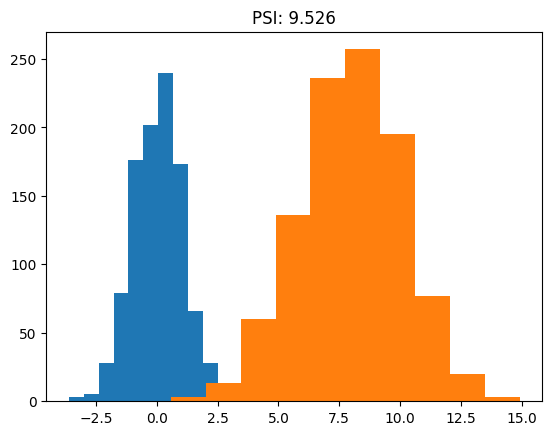

In [368]:
import matplotlib.pyplot as plt

expected = np.random.normal(0, 1, 1000)
actual = np.random.normal(8, 2, 1000)

psi = calculate_psi(expected, actual)
plt.hist(expected)
plt.hist(actual)
plt.title(f"PSI: {psi.round(3)}")
plt.show()

<Axes: xlabel='value', ylabel='Proportion'>

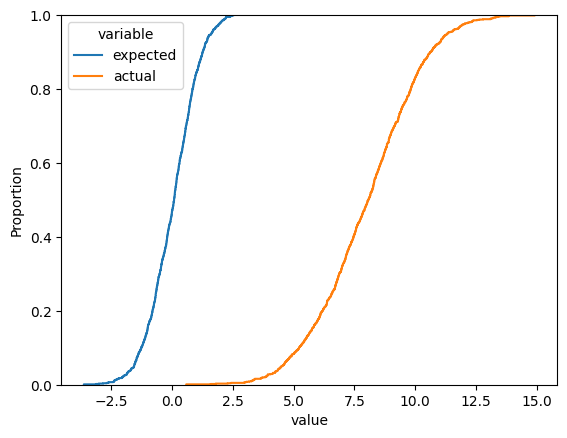

In [369]:
import seaborn as sns

df_plot = pd.DataFrame(zip(expected, actual), columns=["expected", "actual"])
df_plot = df_plot.melt(value_vars=["expected", "actual"])
sns.ecdfplot(data=df_plot, x="value", hue="variable")

Con la misma interfaz de scikit-learn, `feature-engine` ofrece `DropHighPSIFeatures` como un transformador directo:

In [370]:
from feature_engine.selection import DropHighPSIFeatures

# Notar que el split frac se utiliza para separar los datos
transformer = DropHighPSIFeatures(split_frac=0.6)
transformer.fit_transform(X_train.reset_index(drop=True))

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,artist
0,0.630,0.616,1,-8.128,0,0.0309,0.4630,0.040800,0.1730,0.5090,118.650,270773,4,The Rolling Stones
1,0.721,0.949,6,-5.685,1,0.2780,0.0495,0.000000,0.3270,0.8350,83.028,240093,4,Camp Lo
2,0.650,0.900,1,-4.099,0,0.3740,0.0252,0.000000,0.1760,0.6590,89.788,206493,4,Black Star
3,0.770,0.656,10,-11.169,0,0.2460,0.1100,0.000000,0.0793,0.7880,98.820,253413,4,Pete Rock & C.L. Smooth
4,0.617,0.771,10,-5.586,0,0.1120,0.0384,0.000003,0.1620,0.5530,180.002,267747,4,Daddy Yankee
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
646,0.518,0.575,5,-4.616,1,0.0302,0.0259,0.000000,0.1090,0.2090,120.019,340707,4,Harry Styles
647,0.684,0.714,2,-11.001,1,0.0495,0.2010,0.000000,0.0727,0.7630,123.377,383827,4,Harold Melvin & The Blue Notes
648,0.854,0.559,10,-2.516,0,0.0347,0.0083,0.513000,0.1350,0.6390,126.015,159048,4,Valentino Khan
649,0.720,0.823,0,-7.634,1,0.0268,0.0644,0.009480,0.3610,0.8540,120.747,260747,4,Kelly Marie


El transformador expone el PSI calculado por variable, lo que permite identificar cuáles son más inestables y entender por qué serían descartadas:

In [ ]:
transformer.psi_values_

In [ ]:
transformer.features_to_drop_

Al incorporarlo en el `Pipeline`, las variables inestables se eliminan durante el entrenamiento y se ignoran automáticamente en la predicción:

In [373]:
psi_pipeline = Pipeline(
    steps=[
        ("Preprocessing", preprocessing),
        ("psi_selection", DropHighPSIFeatures(split_frac=0.4)),
        ("Tree", DecisionTreeClassifier(random_state=42)),
    ]
)

train_and_evaluate(psi_pipeline)

Matriz de confusión: 

[[17  0  0  0  2  0  0  0  1]
 [ 0  9  1  1  0  1  1  1  3]
 [ 0  4  4  3  0  0  0  0  1]
 [ 0  0  1 17  0  1  1  0  0]
 [ 4  0  0  0  6  1  0  2  1]
 [ 0  0  1  1  0 13  0  2  3]
 [ 0  1  0  5  0  0 11  1  2]
 [ 0  4  2  0  1  1  3  9  0]
 [ 0  6  2  0  1  2  1  6  2]]

Reporte de Clasificación: 

              precision    recall  f1-score   support

     Clasica       0.81      0.85      0.83        20
       Disco       0.38      0.53      0.44        17
 Electronica       0.36      0.33      0.35        12
      Hiphop       0.63      0.85      0.72        20
        Jazz       0.60      0.43      0.50        14
         Pop       0.68      0.65      0.67        20
   Reggaeton       0.65      0.55      0.59        20
        Rock       0.43      0.45      0.44        20
 Rock latino       0.15      0.10      0.12        20

    accuracy                           0.54       163
   macro avg       0.52      0.53      0.52       163
weighted avg       0.53    

0.517891199768865

In [374]:
plot_classification_report_diff(
    classification_report_diff(psi_pipeline),
    title="DropHighPSIFeatures vs Baseline",
)

Para entender qué originó el corte temporal, comparamos la distribución de `energy` en ambas mitades del conjunto de entrenamiento:

In [ ]:
import seaborn as sns

X_train_example = X_train.reset_index(drop=None).copy()
X_train_example["above_cut_off"] = X_train_example.index < transformer.cut_off_
sns.ecdfplot(data=X_train_example, x="energy", hue="above_cut_off")
plt.show()

### Métodos Wrapper

#### Probe: Comparar contra Variables Aleatorias

> **Pregunta motivacional ❓:** Si inventaras una variable completamente aleatoria y la agregaras a tu dataset, ¿debería importarle algo a tu modelo? ¿Qué diría de una variable real si resulta ser menos útil que esa variable inventada?

<center>
<img src='https://substackcdn.com/image/fetch/f_auto,q_auto:good,fl_progressive:steep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2F10f9a8f7-ce4d-46d5-8915-127b5a20d3e0_770x862.gif' width=350 />

Uno de los principales objetivos de la selección de features es eliminar el ruido del conjunto de datos. Una variable generada aleatoriamente, es decir, una feature de prueba, posee inherentemente un alto nivel de ruido. Por lo tanto, cualquier variable que demuestre ser menos importante que una feature de prueba se considera ruido y puede ser descartada del conjunto de datos.

En esta línea, un selector de features que cumple este objetivo es **Probe**, que se enfoca en seleccionar features dentro de un conjunto de datos que tienen un poder predictivo significativamente mayor que una variable aleatoria.

**Probe** genera una o más variables aleatorias basadas en los parámetros seleccionados por el usuario. Luego, el transformador deriva la importancia de cada feature y features de prueba. Finalmente, elimina las features que tienen una puntuación de importancia menor que la(s) feature(s) de prueba.

##### Pasos del Algoritmo

1. Crear una o más features aleatorias.
2. Entrenar un modelo de machine learning con todas las features, incluidas las aleatorias.
3. Derivar la importancia de las features para todas las variables.
4. Calcular la importancia promedio de las features aleatorias (solo si se utilizaron más de una).
5. Seleccionar las features cuya importancia sea mayor que la importancia de las variables aleatorias (paso 4).

En el siguiente ejemplo se usa `RandomForestClassifier` como estimador, precisión como métrica de evaluación, validación cruzada con `cv=5`, y una única variable aleatoria de distribución normal:

In [375]:
from sklearn.ensemble import RandomForestClassifier
from feature_engine.selection import ProbeFeatureSelection

In [378]:
# %%capture
sel = ProbeFeatureSelection(
    estimator=RandomForestClassifier(),
    variables=None,
    scoring="precision",
    n_probes=1,
    distribution="normal",
    cv=5,
    random_state=150,
)

X_probe = sel.fit_transform(X_train, y_train)

Inspeccionamos la variable aleatoria generada para confirmar que tiene la distribución esperada y entender con qué umbral competirán las características reales:

In [377]:
sel.probe_features_.describe()

,gaussian_probe_0
count,651.000000
mean,0.001391
std,3.122366
min,-8.476446
25%,-2.142696
50%,0.052611
75%,2.186219
max,8.460121


La importancia de cada característica —incluida la variable aleatoria— queda registrada para comparar directamente cuáles superan el umbral de descarte:

In [ ]:
sel.feature_importances_

Usar múltiples variables aleatorias con distintas distribuciones hace el criterio de descarte más robusto, ya que el umbral es la importancia **promedio** de todas ellas:

In [380]:
# %%capture
sel = ProbeFeatureSelection(
    estimator=RandomForestClassifier(),
    variables=None,
    scoring="precision",
    n_probes=3,
    distribution="all",
    cv=5,
    random_state=150,
    confirm_variables=False,
)

X_probe = sel.fit(X_train, y_train)

In [381]:
sel.probe_features_.head()

,gaussian_probe_0,gaussian_probe_1,gaussian_probe_2,binary_probe_0,binary_probe_1,binary_probe_2,uniform_probe_0,uniform_probe_1,uniform_probe_2,discrete_uniform_probe_0,discrete_uniform_probe_1,discrete_uniform_probe_2,poisson_probe_0,poisson_probe_1,poisson_probe_2
0,-0.694150,4.049410,-2.565485,1,0,0,0.192038,0.210827,0.295578,3,9,1,13,13,7
1,1.171840,-1.611549,-0.813985,1,0,1,0.265579,0.007264,0.429028,2,5,9,12,11,9
2,1.074892,-0.490751,5.685420,1,1,0,0.107195,0.218936,0.990230,1,9,8,10,18,8
3,1.698733,-1.247894,0.283960,1,0,1,0.742428,0.820399,0.978610,8,0,1,12,7,10
4,0.498702,-4.334988,2.308357,1,1,1,0.709805,0.345836,0.821155,2,3,0,9,5,7


In [382]:
sel.feature_importances_

danceability                0.100607
energy                      0.072420
loudness                    0.080208
speechiness                 0.097890
acousticness                0.077375
instrumentalness            0.060336
liveness                    0.034466
valence                     0.072584
tempo                       0.071818
duration_ms                 0.059050
gaussian_probe_0            0.027306
gaussian_probe_1            0.025093
gaussian_probe_2            0.025265
binary_probe_0              0.004816
binary_probe_1              0.005777
binary_probe_2              0.005540
uniform_probe_0             0.024708
uniform_probe_1             0.023692
uniform_probe_2             0.025390
discrete_uniform_probe_0    0.016821
discrete_uniform_probe_1    0.017120
discrete_uniform_probe_2    0.017024
poisson_probe_0             0.018503
poisson_probe_1             0.017738
poisson_probe_2             0.018451
dtype: float64

> **Pregunta motivacional ❓:** Si tuvieras que elegir solo 3 ingredientes de una receta para replicar el sabor del plato original, ¿cómo los identificarías? ¿Probarías todas las combinaciones posibles, o irías eliminando de a uno los que menos aportan hasta quedarte con los mejores?

❓ Pregunta: ¿Podría utilizarse un algoritmo diferente a RandomForest?

**Respuesta:** Sí. Cualquier estimador que exponga `feature_importances_` puede usarse, por ejemplo `GradientBoostingClassifier` o `ExtraTreesClassifier`. La clave es que el estimador sea capaz de rankear la importancia de cada feature.

#### RFE / RFECV: Eliminación Recursiva de Features

**RFE** es un método *wrapper*: entrena el modelo, obtiene la importancia de cada feature, elimina la menos importante, y repite hasta conservar el número deseado de features.

##### Pasos del Algoritmo

1. Entrenar el modelo con todas las features.
2. Obtener la importancia de cada feature (`feature_importances_` o `coef_`).
3. Eliminar la(s) feature(s) con menor importancia.
4. Repetir desde el paso 1 hasta alcanzar `n_features_to_select`.

La variante **RFECV** agrega validación cruzada en cada paso para determinar automáticamente el número óptimo de features.

In [388]:
from sklearn.feature_selection import RFE, RFECV
from sklearn.tree import DecisionTreeClassifier

# RFE requiere datos numéricos: preprocesamos X_train antes de usarlo
X_train_prep = preprocessing.fit_transform(X_train)
X_test_prep = preprocessing.transform(X_test)

rfe = RFE(
    estimator=DecisionTreeClassifier(random_state=42),
    n_features_to_select=8,
    step=10,  # eliminar 10 features por iteración acelera el proceso con muchas columnas
)

rfe.fit(X_train_prep, y_train)
print(f"Features seleccionadas: {rfe.support_.sum()} de {X_train_prep.shape[1]}")
print("Ranking (1 = seleccionada), primeros 20:", rfe.ranking_[:20])


Features seleccionadas: 8 de 467
Ranking (1 = seleccionada), primeros 20: [ 1  1  2  2 17 25 25 25 24 25 21 25 25 24  2 24 19 24 24 24]


El atributo `ranking_` asigna 1 a las características seleccionadas y valores mayores a las descartadas, indicando el orden en que fueron eliminadas:

In [389]:
import pandas as pd

rfe_results = pd.DataFrame(
    {
        "feature": preprocessing.get_feature_names_out(),
        "seleccionada": rfe.support_,
        "ranking": rfe.ranking_,
    }
).sort_values("ranking")

rfe_results.head(20)


,feature,seleccionada,ranking
0,Scale__duration_ms,True,1
1,Scale__tempo,True,1
464,remainder__instrumentalness,True,1
466,remainder__valence,True,1
463,remainder__acousticness,True,1
462,remainder__speechiness,True,1
461,remainder__energy,True,1
460,remainder__danceability,True,1
3,One Hot Encoding__key_0,False,2
14,One Hot Encoding__key_9,False,2


En lugar de fijar `n_features_to_select` manualmente, `RFECV` usa validación cruzada en cada paso para encontrar automáticamente el número óptimo de características:

In [ ]:
from sklearn.model_selection import StratifiedKFold

rfecv = RFECV(
    estimator=DecisionTreeClassifier(random_state=42),
    step=10,
    cv=StratifiedKFold(5),
    scoring="f1_macro",
    n_jobs=-1,
)

rfecv.fit(X_train_prep, y_train)
print(f"Número óptimo de features: {rfecv.n_features_}")


In [ ]:
import plotly.express as px

cv_scores = rfecv.cv_results_["mean_test_score"]
px.line(
    x=range(1, len(cv_scores) + 1),
    y=cv_scores,
    labels={"x": "Número de features", "y": "F1 macro (CV)"},
    title="RFECV: F1 según número de features conservadas",
)


Al integrarlo en el `Pipeline`, RFE ajusta el estimador interno durante `.fit()` y aplica la máscara de selección en cada `.predict()`, sin pasos manuales intermedios:

In [390]:
rfe_pipeline = Pipeline(
    steps=[
        ("Preprocessing", preprocessing),
        (
            "rfe",
            RFE(
                estimator=DecisionTreeClassifier(random_state=42),
                n_features_to_select=8,
            ),
        ),
        ("model", DecisionTreeClassifier(random_state=42)),
    ]
)

train_and_evaluate(rfe_pipeline)


Matriz de confusión: 

[[17  0  0  0  3  0  0  0  0]
 [ 0  7  2  2  0  1  1  1  3]
 [ 0  3  5  2  0  1  0  1  0]
 [ 0  0  0 15  0  1  3  0  1]
 [ 2  1  0  0  7  1  0  3  0]
 [ 0  0  1  0  0 13  3  2  1]
 [ 0  0  0  5  0  1 12  1  1]
 [ 0  5  4  1  0  0  0  6  4]
 [ 0  4  3  0  1  4  0  4  4]]

Reporte de Clasificación: 

              precision    recall  f1-score   support

     Clasica       0.89      0.85      0.87        20
       Disco       0.35      0.41      0.38        17
 Electronica       0.33      0.42      0.37        12
      Hiphop       0.60      0.75      0.67        20
        Jazz       0.64      0.50      0.56        14
         Pop       0.59      0.65      0.62        20
   Reggaeton       0.63      0.60      0.62        20
        Rock       0.33      0.30      0.32        20
 Rock latino       0.29      0.20      0.24        20

    accuracy                           0.53       163
   macro avg       0.52      0.52      0.51       163
weighted avg       0.53    

0.5147473458859768

In [391]:
plot_classification_report_diff(
    classification_report_diff(rfe_pipeline),
    title="RFE (n=8 features) vs Baseline",
)

> **Pregunta ❓**: ¿Qué ventaja tiene `RFECV` sobre fijar `n_features_to_select` manualmente? ¿En qué casos podría ser problemático usar RFE con un modelo muy lento de entrenar?


### Métodos Embedded

#### SelectFromModel

**SelectFromModel** es un método *embedded*: usa las `feature_importances_` o `coef_` de un modelo ya entrenado para seleccionar las features más relevantes. A diferencia de RFE, **no re-entrena** el modelo iterativamente; usa una sola pasada y aplica un umbral.

El umbral (`threshold`) puede ser:
- Un número fijo (ej. `0.05`).
- `"mean"`: elimina features con importancia menor al promedio.
- `"median"`: elimina features con importancia menor a la mediana.

In [392]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

# Entrenamos sobre datos preprocesados (X_train_prep definido en la sección RFE)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_prep, y_train)

selector = SelectFromModel(rf, threshold="mean", prefit=True)
X_train_sfm = selector.transform(X_train_prep)
print(f"Features originales:    {X_train_prep.shape[1]}")
print(f"Features seleccionadas: {X_train_sfm.shape[1]}")


Features originales:    467
Features seleccionadas: 28


El siguiente gráfico muestra la importancia de cada característica para tres modelos distintos. Las barras azules superan el umbral seleccionado y serían conservadas; las grises, descartadas:

In [393]:
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
)
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import pandas as pd

models_sfm = {
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "ExtraTrees": ExtraTreesClassifier(n_estimators=100, random_state=42),
}

# Entrenamos los tres modelos y recopilamos importancias
importances_dict = {}
for name, model in models_sfm.items():
    model.fit(X_train_prep, y_train)
    importances_dict[name] = (
        pd.DataFrame(
            {
                "feature": preprocessing.get_feature_names_out(),
                "importancia": model.feature_importances_,
            }
        )
        .sort_values("importancia", ascending=False)
        .reset_index(drop=True)
    )

model_names = list(models_sfm.keys())
threshold_options = [
    ("mean", "Umbral: media"),
    ("median", "Umbral: mediana"),
    (0.05, "Umbral: 0.05"),
]

fig = make_subplots(rows=1, cols=3, subplot_titles=model_names)

for t_idx, (thresh, _) in enumerate(threshold_options):
    for m_idx, name in enumerate(model_names):
        imp_df = importances_dict[name]
        if thresh == "mean":
            thresh_val = imp_df["importancia"].mean()
        elif thresh == "median":
            thresh_val = imp_df["importancia"].median()
        else:
            thresh_val = thresh
        colors = [
            "#1f77b4" if v >= thresh_val else "#d3d3d3" for v in imp_df["importancia"]
        ]
        fig.add_trace(
            go.Bar(
                x=imp_df["feature"],
                y=imp_df["importancia"],
                marker_color=colors,
                visible=(t_idx == 0),
                showlegend=False,
                hovertemplate="%{x}<br>Importancia: %{y:.4f}<extra></extra>",
            ),
            row=1,
            col=m_idx + 1,
        )

n_per_thresh = len(model_names)
buttons = []
for t_idx, (_, label) in enumerate(threshold_options):
    visible = [False] * (len(threshold_options) * n_per_thresh)
    for m_idx in range(n_per_thresh):
        visible[t_idx * n_per_thresh + m_idx] = True
    buttons.append(dict(label=label, method="update", args=[{"visible": visible}]))

fig.update_layout(
    updatemenus=[
        dict(
            type="dropdown",
            buttons=buttons,
            direction="down",
            x=0.5,
            xanchor="center",
            y=1.20,
            yanchor="top",
            showactive=True,
        )
    ],
    title=(
        "SelectFromModel: Importancia de features por modelo<br>"
        "<sub>Azul = seleccionada · Gris = descartada · Dropdown para cambiar umbral</sub>"
    ),
    height=520,
)
fig.update_xaxes(tickangle=45, tickfont_size=8)
fig.show()


A diferencia de RFE, `SelectFromModel` entrena el estimador interno **una sola vez**, lo que lo hace significativamente más rápido en pipelines con modelos costosos:

In [394]:
sfm_pipeline = Pipeline(
    steps=[
        ("Preprocessing", preprocessing),
        (
            "sfm",
            SelectFromModel(
                RandomForestClassifier(n_estimators=100, random_state=42),
                threshold="mean",
            ),
        ),
        ("model", DecisionTreeClassifier(random_state=42)),
    ]
)

train_and_evaluate(sfm_pipeline)


Matriz de confusión: 

[[17  0  0  0  3  0  0  0  0]
 [ 0  8  2  1  0  1  1  1  3]
 [ 0  1  5  2  0  0  0  2  2]
 [ 0  0  0 16  0  1  1  2  0]
 [ 3  1  0  0  7  1  0  2  0]
 [ 0  2  1  2  1 13  0  1  0]
 [ 0  1  0  5  0  1 11  1  1]
 [ 0  3  1  0  0  0  1 13  2]
 [ 0  7  2  0  1  2  0  5  3]]

Reporte de Clasificación: 

              precision    recall  f1-score   support

     Clasica       0.85      0.85      0.85        20
       Disco       0.35      0.47      0.40        17
 Electronica       0.45      0.42      0.43        12
      Hiphop       0.62      0.80      0.70        20
        Jazz       0.58      0.50      0.54        14
         Pop       0.68      0.65      0.67        20
   Reggaeton       0.79      0.55      0.65        20
        Rock       0.48      0.65      0.55        20
 Rock latino       0.27      0.15      0.19        20

    accuracy                           0.57       163
   macro avg       0.56      0.56      0.55       163
weighted avg       0.57    

0.5532624097471986

In [395]:
plot_classification_report_diff(
    classification_report_diff(sfm_pipeline),
    title="SelectFromModel (RF, umbral=mean) vs Baseline",
)

> **Pregunta ❓**: ¿Por qué `SelectFromModel` con Random Forest es más rápido que `RFE` con el mismo estimador? ¿Qué se pierde a cambio?


### Métodos de Filtro Estadístico

<center>
<img src='https://i.gifer.com/origin/c9/c9be3e27aac9ecddc6c7e64aad70d8df_w200.gif' width=350 />

Compara las características con las etiquetas a través de test estadísticos simples e ignora la relación entre las características en sí. Para ocupar este tipo de técnicas se requiere una métrica y una estrategia

#### Métricas

- Varias métricas para clasificación: 
    - Anova (`f_classif`). La idea es calcular un estadístico F-score, el cuál indica que tan fácil es para un atributo distinguir entre clases. Más información [aquí](https://datascience.stackexchange.com/questions/74465/how-to-understand-anova-f-for-feature-selection-in-python-sklearn-selectkbest-w).
    - Mutual information (`mutual_info_classif`) es un estadístico que mide la independencia entre dos variables aleatorias. 0 indica independencia entre variables. Valores más altos indican mayor dependencia. En general da mejores resultados que `f_classif`, pero su implementación es más lenta.
    - Chi squared (`chi2`) realiza un test estadístico $\chi^2$ que, al igual que la función anterior, mide la dependencia entre distintas variables. Sirve solo con variables categóricas (en OneHot) o conteos (como Bag of Words).
    
- Para regresión, se usan otro tipo de métricas especializadas en ellas.
- Referencia: [Univariate Feature Selection](https://scikit-learn.org/stable/modules/feature_selection.html#univariate-feature-selection).

#### Estrategias

Definen como se seleccionarán las mejores características: 

- `SelectKBest` selecciona las features con los mejores valores. Hay que especificar el número de features que seleccionaremos.

- `SelectPercentile` selecciona el porcentaje con mejores valores. Hay que especificar con cuanto porcentaje quedarse.

#### Integrar la Selección de Características al Pipeline

La búsqueda de mejores características se realiza al momento de entrenar un pipeline. Luego, al momento de predecir, el selector de características simplemente descarta las características no utilizadas antes de pasar a la siguiente etapa. El siguiente ejemplo muestra lo anteriormente dicho:

In [396]:
from sklearn.feature_selection import (
    SelectKBest,
    SelectPercentile,
    f_classif,
    mutual_info_classif,
)

selection_pipeline = Pipeline(
    steps=[
        ("Preprocessing", preprocessing),
        # Conservamos el 70% mejor según la métrica seleccionada
        ("Selection", SelectPercentile(f_classif, percentile=70)),
        ("Tree", DecisionTreeClassifier(random_state=42)),
    ]
)

train_and_evaluate(selection_pipeline)

Matriz de confusión: 

[[17  0  0  0  3  0  0  0  0]
 [ 0  9  1  1  0  1  1  1  3]
 [ 0  2  5  3  0  0  0  1  1]
 [ 0  0  0 17  0  1  1  1  0]
 [ 4  0  0  0  6  1  0  2  1]
 [ 0  0  1  0  0 13  1  1  4]
 [ 0  2  0  4  0  0 12  1  1]
 [ 0  3  2  0  1  1  2  9  2]
 [ 0  5  3  0  1  2  0  5  4]]

Reporte de Clasificación: 

              precision    recall  f1-score   support

     Clasica       0.81      0.85      0.83        20
       Disco       0.43      0.53      0.47        17
 Electronica       0.42      0.42      0.42        12
      Hiphop       0.68      0.85      0.76        20
        Jazz       0.55      0.43      0.48        14
         Pop       0.68      0.65      0.67        20
   Reggaeton       0.71      0.60      0.65        20
        Rock       0.43      0.45      0.44        20
 Rock latino       0.25      0.20      0.22        20

    accuracy                           0.56       163
   macro avg       0.55      0.55      0.55       163
weighted avg       0.56    

0.5479707392458784

In [397]:
plot_classification_report_diff(
    classification_report_diff(selection_pipeline),
    title="SelectPercentile f_classif (70%) vs Baseline",
)

In [398]:
selection_pipeline = Pipeline(
    steps=[
        ("Preprocessing", preprocessing),
        ("Selection", SelectPercentile(f_classif, percentile=20)),
        ("Tree", DecisionTreeClassifier(random_state=42)),
    ]
)

train_and_evaluate(selection_pipeline)

Matriz de confusión: 

[[17  0  0  0  2  0  0  0  1]
 [ 0  8  2  1  0  1  1  1  3]
 [ 0  2  6  3  0  0  1  0  0]
 [ 0  0  0 17  0  1  1  0  1]
 [ 4  0  0  0  6  1  0  2  1]
 [ 0  1  1  1  1 13  0  2  1]
 [ 0  1  0  4  0  1 11  2  1]
 [ 0  4  1  0  0  2  2  7  4]
 [ 0  6  3  0  1  3  0  4  3]]

Reporte de Clasificación: 

              precision    recall  f1-score   support

     Clasica       0.81      0.85      0.83        20
       Disco       0.36      0.47      0.41        17
 Electronica       0.46      0.50      0.48        12
      Hiphop       0.65      0.85      0.74        20
        Jazz       0.60      0.43      0.50        14
         Pop       0.59      0.65      0.62        20
   Reggaeton       0.69      0.55      0.61        20
        Rock       0.39      0.35      0.37        20
 Rock latino       0.20      0.15      0.17        20

    accuracy                           0.54       163
   macro avg       0.53      0.53      0.53       163
weighted avg       0.53    

0.5254070546600917

In [399]:
plot_classification_report_diff(
    classification_report_diff(selection_pipeline),
    title="SelectPercentile f_classif (20%) vs Baseline",
)

In [ ]:
selection_pipeline = Pipeline(
    steps=[
        ("Preprocessing", preprocessing),
        ("Selection", SelectPercentile(mutual_info_classif, percentile=20)),
        ("Tree", DecisionTreeClassifier(random_state=42)),
    ]
)

train_and_evaluate(selection_pipeline)

In [401]:
plot_classification_report_diff(
    classification_report_diff(selection_pipeline),
    title="SelectPercentile mutual_info (20%) vs Baseline",
)

> **Pregunta: ❓** ¿Cómo elegir el mejor porcentaje de features por conservar? ¿Y la métrica?

In [ ]:
selection_pipeline.steps[1][1]

In [ ]:
selection_pipeline.steps[1][1].percentile

In [400]:
from sklearn.feature_selection import f_classif
import plotly.graph_objects as go
import numpy as np

# Ajustamos preprocessing y calculamos scores con f_classif
prep_fitted = preprocessing.fit(X_train)
X_prep = prep_fitted.transform(X_train)
feature_names_out = prep_fitted.get_feature_names_out()

scores, _ = f_classif(X_prep, y_train)
scores = np.nan_to_num(scores, nan=0.0)

# Ordenamos de mayor a menor score
sorted_idx = np.argsort(scores)[::-1]
sorted_scores = scores[sorted_idx]
sorted_names = feature_names_out[sorted_idx]
n_feat = len(sorted_scores)

percentiles = list(range(10, 101, 10))
fig = go.Figure()

for perc in percentiles:
    n_select = max(1, int(np.ceil(n_feat * perc / 100)))
    colors = ["#1f77b4"] * n_select + ["#d3d3d3"] * (n_feat - n_select)
    fig.add_trace(
        go.Bar(
            x=list(range(n_feat)),
            y=sorted_scores,
            marker_color=colors,
            visible=(perc == 50),
            hovertext=list(sorted_names),
            hovertemplate="%{hovertext}<br>Score: %{y:.2f}<extra></extra>",
        )
    )

steps = [
    dict(
        method="update",
        args=[{"visible": [j == i for j in range(len(percentiles))]}],
        label=f"{perc}%",
    )
    for i, perc in enumerate(percentiles)
]

fig.update_layout(
    sliders=[
        dict(
            active=4,
            currentvalue={"prefix": "Percentil conservado: "},
            pad={"t": 50},
            steps=steps,
        )
    ],
    title=(
        "SelectPercentile: Features seleccionadas según percentil<br>"
        "<sub>Azul = seleccionada · Gris = descartada · Hover para ver nombre</sub>"
    ),
    xaxis_title="Feature (ordenadas por score f_classif, hover para nombre)",
    yaxis_title="Score f_classif",
    showlegend=False,
    height=450,
)
fig.show()


## Optimización de Hiperparámetros

<center>
<img src='https://media3.giphy.com/media/42wQXwITfQbDGKqUP7/giphy.gif?cid=6c09b952u0a9kwn7ryl9mz4nhhp82i0lvayupiwrvd4lz1bw&ep=v1_gifs_search&rid=giphy.gif&ct=g' width=250 />

Si bien el ciclo anterior nos permitió encontrar el mejor valor para el porcentaje de la selección de atributos, es bastante trabajo implementarlo, pensando más aún que comúnmente se quieren optimizar varias partes del pipeline y no solo un paso en específico.

En el caso anterior, un ejemplo de esto podría ser variar el porcentaje **y** la métrica usada simultáneamente. Esto genera una **malla de búsqueda (grid)** con todas las combinaciones posibles del producto cartesiano:

| `score_func` | `percentile` |
|---|---|
| `f_classif` | 10 |
| `f_classif` | 20 |
| ... | ... |
| `f_classif` | 100 |
| `mutual_info_classif` | 10 |
| `mutual_info_classif` | 20 |
| ... | ... |
| `mutual_info_classif` | 100 |

En total: 2 métricas × 10 percentiles = **20 combinaciones** que evaluar. A medida que crecen los hiperparámetros, el número de combinaciones crece exponencialmente.

Por esto, la idea es tener un mecanismo al cual podamos pasarle una lista de hiperparámetros, que los pruebe todos y que retorne el mejor modelo. 
Este mecanismo en `scikit-learn` es conocido como Búsqueda de Grilla o `GridSearch`.

### GridSearchCV

#### Encontrar los Parámetros Disponibles

En general, cualquier clase de scikit-learn implementa la función `get_params`, la cual muestra los parámetros disponibles para probar y modificar.

In [402]:
SelectPercentile().get_params()

{'percentile': 10,
 'score_func': <function sklearn.feature_selection._univariate_selection.f_classif(X, y)>}

Para el caso de una `Pipeline`, muestra las `steps` de la pipeline más los parámetros de cada una de las steps. 
Noten que los parámetros de cada `step` siguen la notación: `{nombre_step}__{parámetro_step}`

Ejemplo: Número de porcentajes que escogeremos - `Selection__percentile`



In [403]:
selection_pipeline = Pipeline(
    steps=[
        ("Preprocessing", preprocessing),
        ("Selection", SelectPercentile(f_classif, percentile=20)),
        ("Tree", DecisionTreeClassifier(random_state=42)),
    ]
)

selection_pipeline.get_params()

{'memory': None,
 'steps': [('Preprocessing',
   ColumnTransformer(remainder='passthrough',
                     transformers=[('Scale', MinMaxScaler(),
                                    ['duration_ms', 'tempo', 'loudness']),
                                   ('One Hot Encoding',
                                    OneHotEncoder(handle_unknown='ignore',
                                                  sparse_output=False),
                                    ['key', 'mode', 'artist', 'time_signature'])])),
  ('Selection', SelectPercentile(percentile=20)),
  ('Tree', DecisionTreeClassifier(random_state=42))],
 'transform_input': None,
 'verbose': False,
 'Preprocessing': ColumnTransformer(remainder='passthrough',
                   transformers=[('Scale', MinMaxScaler(),
                                  ['duration_ms', 'tempo', 'loudness']),
                                 ('One Hot Encoding',
                                  OneHotEncoder(handle_unknown='ignore',
               

La idea es definir un grilla de hiperparámetros para que GridSearch los explore y elija el mejor.

In [405]:
param_grid = [{"Selection__percentile": list(range(10, 101, 5))}]
param_grid

[{'Selection__percentile': [10,
   15,
   20,
   25,
   30,
   35,
   40,
   45,
   50,
   55,
   60,
   65,
   70,
   75,
   80,
   85,
   90,
   95,
   100]}]

Y luego invocar GridSearch con el Pipeline, la grilla de hiperparámetros, la métrica (pueden ver las métricas disponibles [aquí](https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter)) y la cantidad de cores de su CPU que deseen usar:

In [406]:
from sklearn.model_selection import GridSearchCV

gs = GridSearchCV(selection_pipeline, param_grid, n_jobs=-1, scoring="f1_macro")
train_and_evaluate(gs)

Matriz de confusión: 

[[17  0  0  0  3  0  0  0  0]
 [ 0  8  1  2  1  1  1  1  2]
 [ 0  2  5  3  1  0  1  0  0]
 [ 0  0  1 17  0  1  1  0  0]
 [ 4  1  0  0  6  1  0  2  0]
 [ 0  1  1  0  0 13  1  2  2]
 [ 0  2  0  4  0  0 12  1  1]
 [ 0  3  2  1  1  1  1  9  2]
 [ 0  6  3  0  1  2  0  5  3]]

Reporte de Clasificación: 

              precision    recall  f1-score   support

     Clasica       0.81      0.85      0.83        20
       Disco       0.35      0.47      0.40        17
 Electronica       0.38      0.42      0.40        12
      Hiphop       0.63      0.85      0.72        20
        Jazz       0.46      0.43      0.44        14
         Pop       0.68      0.65      0.67        20
   Reggaeton       0.71      0.60      0.65        20
        Rock       0.45      0.45      0.45        20
 Rock latino       0.30      0.15      0.20        20

    accuracy                           0.55       163
   macro avg       0.53      0.54      0.53       163
weighted avg       0.54    

0.5291591453068707

In [407]:
plot_classification_report_diff(
    classification_report_diff(gs),
    title="GridSearchCV (SelectPercentile f_classif) vs Baseline",
)

In [408]:
gs.best_params_

{'Selection__percentile': 85}

El atributo `best_estimator_` entrega el pipeline completo ya reentrenado con la mejor combinación encontrada, listo para predecir:

In [409]:
gs.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Preprocessing', ...), ('Selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Scale', ...), ('One Hot Encoding', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output 

#### Ejemplo de Predicción

In [410]:
# sacamos el vector de los atributos desde las features
gs.predict(X_test)

array(['Jazz', 'Rock latino', 'Reggaeton', 'Electronica', 'Clasica',
       'Hiphop', 'Electronica', 'Hiphop', 'Hiphop', 'Hiphop', 'Pop',
       'Hiphop', 'Rock latino', 'Jazz', 'Clasica', 'Disco', 'Pop', 'Rock',
       'Disco', 'Rock', 'Jazz', 'Clasica', 'Electronica', 'Pop',
       'Clasica', 'Reggaeton', 'Hiphop', 'Rock', 'Rock latino',
       'Reggaeton', 'Reggaeton', 'Rock latino', 'Disco', 'Disco',
       'Hiphop', 'Clasica', 'Rock', 'Disco', 'Clasica', 'Disco', 'Hiphop',
       'Rock latino', 'Rock', 'Disco', 'Clasica', 'Rock', 'Reggaeton',
       'Rock latino', 'Reggaeton', 'Electronica', 'Disco', 'Hiphop',
       'Reggaeton', 'Reggaeton', 'Pop', 'Hiphop', 'Rock', 'Rock latino',
       'Reggaeton', 'Hiphop', 'Rock', 'Pop', 'Pop', 'Jazz', 'Disco',
       'Jazz', 'Hiphop', 'Pop', 'Clasica', 'Disco', 'Jazz', 'Hiphop',
       'Jazz', 'Hiphop', 'Rock latino', 'Rock', 'Electronica', 'Jazz',
       'Hiphop', 'Clasica', 'Disco', 'Pop', 'Reggaeton', 'Disco',
       'Hiphop', 'Pop', 'Dis

> **Pregunta ❓**: ¿Y si ahora quiero usar otra métrica univariada para seleccionar atributos?

Por ejemplo, [`Mutual information`](https://en.wikipedia.org/wiki/Mutual_information)
Vamos nuevamente a buscar el nombre del atributo que queremos modificar y ejecutamos nuevamente grid-search.

In [411]:
selection_pipeline = Pipeline(
    steps=[
        ("Preprocessing", preprocessing),
        ("Selection", SelectPercentile(mutual_info_classif, percentile=20)),
        ("Tree", DecisionTreeClassifier(random_state=42)),
    ]
)

param_grid = [
    {
        "Selection__percentile": range(5, 101, 5),
        "Selection__score_func": [f_classif, mutual_info_classif],
    }
]

In [412]:
gs2 = GridSearchCV(selection_pipeline, param_grid, n_jobs=-1, scoring="f1_macro")
train_and_evaluate(gs2)

Matriz de confusión: 

[[17  0  0  0  3  0  0  0  0]
 [ 0  8  1  2  1  1  1  1  2]
 [ 0  2  5  3  1  0  1  0  0]
 [ 0  0  1 17  0  1  1  0  0]
 [ 4  1  0  0  6  1  0  2  0]
 [ 0  1  1  0  0 13  1  2  2]
 [ 0  2  0  4  0  0 12  1  1]
 [ 0  3  2  1  1  1  1  9  2]
 [ 0  6  3  0  1  2  0  5  3]]

Reporte de Clasificación: 

              precision    recall  f1-score   support

     Clasica       0.81      0.85      0.83        20
       Disco       0.35      0.47      0.40        17
 Electronica       0.38      0.42      0.40        12
      Hiphop       0.63      0.85      0.72        20
        Jazz       0.46      0.43      0.44        14
         Pop       0.68      0.65      0.67        20
   Reggaeton       0.71      0.60      0.65        20
        Rock       0.45      0.45      0.45        20
 Rock latino       0.30      0.15      0.20        20

    accuracy                           0.55       163
   macro avg       0.53      0.54      0.53       163
weighted avg       0.54    

0.5291591453068707

In [413]:
plot_classification_report_diff(
    classification_report_diff(gs2),
    title="GridSearchCV (SelectPercentile + mutual_info) vs Baseline",
)

In [414]:
gs2.best_score_

np.float64(0.5504056166054988)

In [415]:
gs2.best_params_

{'Selection__percentile': 90,
 'Selection__score_func': <function sklearn.feature_selection._mutual_info.mutual_info_classif(X, y, *, discrete_features='auto', n_neighbors=3, copy=True, random_state=None, n_jobs=None)>}

> **Pregunta ❓**: ¿Podemos entonces también cambiar el clasificador y probar varios tipos?
    

#### Probando Múltiples Clasificadores

Efectivamente, la notación permite generar distintas grillas de búsqueda para distintos clasificadores a través de la definición de distintos diccionarios dentro de la lista que se le provee a GridSearch:


```
[
    # grilla 1
    {
     'modelo' : [Modelo1()],
     'modelo__param1': ...
    },
    # grilla 2
    {
     'modelo' : [Modelo1()],
     'modelo__param1': ...
    }, 
    ...

]
```

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

pipe = Pipeline(
    [
        ("preprocessing", preprocessing),
        ("selection", SelectPercentile(f_classif)),
        ("model", KNeighborsClassifier()),
    ]
)

pipe.get_params()

In [ ]:
DecisionTreeClassifier().get_params()

In [ ]:
grid = [
    # grilla 1: tree
    {
        "selection__percentile": range(10, 101, 10),
        "model": [DecisionTreeClassifier()],
        "model__criterion": ["gini", "entropy"],
    },
    # grilla 2: knn
    {
        "selection__percentile": range(10, 101, 10),
        "model": [KNeighborsClassifier()],
        "model__n_neighbors": [2, 4, 5, 10],
    },
    # grilla 3: random forest
    {
        "model": [RandomForestClassifier()],
        "model__criterion": ["gini", "entropy"],
        "model__bootstrap": [True, False],
    },
]

In [ ]:
gs3 = GridSearchCV(pipe, grid, n_jobs=-1, scoring="f1_macro").fit(X_train, y_train)

In [ ]:
train_and_evaluate(gs3)

In [ ]:
plot_classification_report_diff(
    classification_report_diff(gs3),
    title="GridSearchCV (múltiples clasificadores) vs Baseline",
)

> **Pregunta motivacional ❓:** En un concurso de talentos con 100 participantes, ¿escucharías a todos por igual durante todo el tiempo disponible? ¿O eliminarías rápido a los menos prometedores y dedicarías más tiempo a los finalistas? ¿En qué se parece eso a lo que hace HalvingGridSearch y Optuna comparado con GridSearch?

In [ ]:
gs3.best_params_

GridSearch evalúa **todas** las combinaciones posibles de hiperparámetros, lo que puede volverse muy costoso cuando el espacio de búsqueda crece. Las siguientes alternativas abordan este problema de formas distintas.

### HalvingGridSearchCV

El funcionamiento de HalvingGridSearchCV se basa en un enfoque iterativo y progresivo. Inicialmente, explora muchas combinaciones de hiperparámetros utilizando una pequeña porción del conjunto de datos. Esto permite evaluar rápidamente cuáles combinaciones tienen más potencial sin invertir demasiado tiempo y recursos en el proceso inicial. A medida que avanza, el algoritmo elimina las combinaciones menos prometedoras y retiene solo las mejores. En cada ronda sucesiva, aumenta gradualmente la cantidad de datos y recursos asignados a las combinaciones que siguen en la competencia.

<br>

<div align='center'>
<img src="../../recursos/2025-01/10-Feature_selection/halving_2.PNG?raw=true" width=500/>
</div>

In [ ]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import f_classif, mutual_info_classif
from sklearn.pipeline import Pipeline
import warnings

warnings.filterwarnings("ignore")

selection_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessing),
        ("selection", SelectPercentile(mutual_info_classif, percentile=20)),
        ("model", RandomForestClassifier()),
    ]
)

param_grid = [
    {
        "selection__percentile": range(5, 101, 10),
        "model__criterion": ["gini", "entropy"],
        "model__bootstrap": [True, False],
    }
]

hgs = HalvingGridSearchCV(selection_pipeline, param_grid, n_jobs=-1, scoring="f1_macro")

train_and_evaluate(hgs)

In [ ]:
plot_classification_report_diff(
    classification_report_diff(hgs),
    title="HalvingGridSearchCV vs Baseline",
)

### Optuna

Optuna es una biblioteca de código abierto para la optimización automática de hiperparámetros. A diferencia de GridSearch, no evalúa todas las combinaciones posibles: usa **optimización bayesiana** para explorar el espacio de búsqueda de forma inteligente, concentrándose en las regiones más prometedoras.

El flujo de trabajo básico es:

1. **Definir el espacio de búsqueda**: rangos de valores posibles para cada hiperparámetro.
2. **Definir la función objetivo**: recibe un conjunto de hiperparámetros y retorna la métrica a maximizar/minimizar.
3. **Crear un `study` y optimizar**: Optuna muestrea, evalúa y aprende iterativamente qué configuraciones son mejores.
4. **Definir criterios de parada**: número máximo de trials o umbral de rendimiento.

Optuna también soporta **pruning** (poda): interrumpe tempranamente los trials que claramente no llevarán a buenos resultados, ahorrando tiempo de cómputo.

#### Tree-structured Parzen Estimator (TPE)

El algoritmo por defecto de Optuna es **TPE**, que construye dos modelos probabilísticos: uno para las configuraciones que dieron buenos resultados y otro para las que dieron malos resultados. En cada iteración, sugiere hiperparámetros que maximizan el ratio entre ambos modelos, equilibrando **exploración** (nuevas regiones del espacio) y **explotación** (refinar zonas prometedoras).

![](https://tech.preferred.jp/wp-content/uploads/2020/10/image3.gif)

In [ ]:
import optuna
from optuna.visualization import plot_optimization_history
from optuna.visualization import plot_parallel_coordinate
from optuna.visualization import plot_param_importances

In [ ]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

In [ ]:
# Define your objective function to maximize aucpr
def objective_function(trial):
    # Split into features and target
    le = LabelEncoder()
    y = le.fit_transform(df.loc[:, "genre"])
    X = df.drop(columns=["genre", "id", "name", "artist"]).astype(float)

    # Split into train and validation sets
    X_train, X_valid, y_train, y_valid = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Define the hyperparameters to tune
    params = {
        "objective": "multi:softmax",
        "eval_metric": "mlogloss",
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.1, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 7),
        "gamma": trial.suggest_float("gamma", 0, 1),
        "n_estimators": trial.suggest_int("n_estimators", 10, 300),
    }

    # Train the XGBoost model with prunning
    pruning_callback = optuna.integration.XGBoostPruningCallback(
        trial, observation_key="validation_1-mlogloss"
    )
    model = XGBClassifier(seed=42, **params)
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_train, y_train), (X_valid, y_valid)],
    )

    # Predict and evaluate the model
    yhat = model.predict(X_valid)
    f1 = f1_score(y_valid, yhat, average="weighted")

    return f1

Notar que el prunning permitirá "podar" todos aquellos intentos que tienden a disminuir el desempeño final del modelo:

<center>
<img src='https://editor.analyticsvidhya.com/uploads/58727o1.png' width=350 />

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective_function, n_trials=25)

#### Visualizaciones

In [ ]:
import plotly.graph_objects as go

trials_df = study.trials_dataframe()
trials_df = trials_df[trials_df["state"] == "COMPLETE"].reset_index(drop=True)
best_so_far = trials_df["value"].cummax()

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=trials_df["number"],
        y=trials_df["value"],
        mode="markers",
        name="Trial",
        marker=dict(color="#636EFA", size=7, opacity=0.7),
    )
)
fig.add_trace(
    go.Scatter(
        x=trials_df["number"],
        y=best_so_far,
        mode="lines",
        name="Mejor hasta ahora",
        line=dict(color="#EF553B", width=2.5),
    )
)

fig.update_layout(
    title="Optuna: Historial de Optimización",
    xaxis=dict(
        title="Número de trial",
        rangeslider=dict(visible=True, thickness=0.08),
        type="linear",
    ),
    yaxis_title="F1 Score (weighted)",
    legend=dict(yanchor="bottom", y=0.05, xanchor="right", x=0.99),
    height=480,
)
fig.show()


In [ ]:
plot_parallel_coordinate(study)

In [ ]:
plot_param_importances(study)

In [ ]:
print(study.best_trial.value)

In [ ]:
print(study.best_trial.params)

In [ ]:
study.trials_dataframe()

In [ ]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

le = LabelEncoder()
y_opt = le.fit_transform(df.loc[:, "genre"])
X_opt = df.drop(columns=["genre", "id", "name", "artist"]).astype(float)

X_tr_opt, X_te_opt, y_tr_opt, y_te_opt = train_test_split(
    X_opt, y_opt, test_size=0.2, random_state=42
)

best_model = XGBClassifier(
    objective="multi:softmax",
    eval_metric="mlogloss",
    seed=42,
    **study.best_trial.params,
)
best_model.fit(X_tr_opt, y_tr_opt)

y_pred_labels = le.inverse_transform(best_model.predict(X_te_opt))
y_test_labels = le.inverse_transform(y_te_opt)

df_optuna = pd.DataFrame(
    classification_report(y_test_labels, y_pred_labels, output_dict=True)
).T

diff_optuna = (
    (df_optuna - _baseline_report) / _baseline_report.replace(0, np.nan).abs() * 100
)
plot_classification_report_diff(
    diff_optuna[["precision", "recall", "f1-score"]],
    title="Optuna — XGBoost (mejores hiperparámetros) vs Baseline",
)
